# Week 4: Advanced Model Evaluation, Hyperparameter Tuning and Reporting

## Telco Customer Churn Prediction

### Objective

The objective of Week 4 is to improve the Decision Tree churn-prediction model developed in Week 3 through cross-validation, hyperparameter tuning, advanced performance evaluation, and final model comparison.

The project uses RandomizedSearchCV to tune important Decision Tree parameters and evaluates the baseline and tuned models using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, ROC curves, precision-recall curves, and cross-validation scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import io

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

os.makedirs("week4_graphs", exist_ok=True)

print("Week 4 libraries imported successfully.")

Week 4 libraries imported successfully.


In [2]:
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df_model = df.drop(columns=["customerID"]).copy()

df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"].replace(r"^\s*$", np.nan, regex=True),
    errors="coerce"
)

df_model.loc[
    (df_model["tenure"] == 0) & (df_model["TotalCharges"].isna()),
    "TotalCharges"
] = 0

df_model["TotalCharges"] = df_model["TotalCharges"].fillna(
    df_model["TotalCharges"].median()
)

df_model["Churn"] = df_model["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Dataset shape:", df_model.shape)
print("Missing values:", df_model.isnull().sum().sum())
print(df_model["Churn"].value_counts())

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
Dataset shape: (7043, 20)
Missing values: 0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_model["TotalServices"] = (
    df_model[service_columns]
    .apply(lambda col: (col == "Yes").astype(int))
    .sum(axis=1)
)

df_model["AvgMonthlySpend"] = np.where(
    df_model["tenure"] > 0,
    df_model["TotalCharges"] / df_model["tenure"],
    df_model["MonthlyCharges"]
)

df_model["TenureGroup"] = pd.cut(
    df_model["tenure"],
    bins=[-1, 12, 36, 60, 72],
    labels=["0-12 months", "13-36 months", "37-60 months", "61-72 months"]
)

df_model["HasPartnerOrDependents"] = (
    (df_model["Partner"] == "Yes") |
    (df_model["Dependents"] == "Yes")
).astype(int)

df_model["AutoPayment"] = df_model["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)

df_model["IsMonthToMonth"] = (
    df_model["Contract"] == "Month-to-month"
).astype(int)

df_model["ChargePerService"] = (
    df_model["MonthlyCharges"] /
    df_model["TotalServices"].replace(0, 1)
)

print("Feature engineering completed.")
display(df_model.head())

Feature engineering completed.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,AvgMonthlySpend,TenureGroup,HasPartnerOrDependents,AutoPayment,IsMonthToMonth,ChargePerService
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,0,1,29.8500,0-12 months,1,0,1,29.8500
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,0,3,55.5735,13-36 months,0,0,0,18.9833
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,1,3,54.0750,0-12 months,0,0,1,17.9500
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.7500,0,3,40.9056,37-60 months,0,1,0,14.1000
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,1,1,75.8250,0-12 months,0,0,1,70.7000


In [4]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5634, 26)
Testing shape: (1409, 26)


In [5]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced"
    ))
])

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Decision Tree trained successfully.")

Baseline Decision Tree trained successfully.


In [6]:
def calculate_metrics(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1-score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

baseline_metrics = calculate_metrics(
    y_test,
    baseline_predictions,
    baseline_probabilities
)

print("BASELINE DECISION TREE PERFORMANCE")
print("-" * 40)

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, baseline_predictions))

BASELINE DECISION TREE PERFORMANCE
----------------------------------------
Accuracy: 0.7516
Precision: 0.5220
Recall: 0.7620
F1-score: 0.6196
ROC-AUC: 0.8353

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    n_jobs=-1
)

baseline_cv_results = pd.DataFrame({
    "Accuracy": baseline_cv["test_accuracy"],
    "Precision": baseline_cv["test_precision"],
    "Recall": baseline_cv["test_recall"],
    "F1-score": baseline_cv["test_f1"],
    "ROC-AUC": baseline_cv["test_roc_auc"]
})

display(baseline_cv_results)

print("\nBASELINE CROSS-VALIDATION MEAN SCORES")
display(baseline_cv_results.agg(["mean", "std"]).T)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.7551,0.5277,0.7324,0.6134,0.8170
1,0.7374,0.5033,0.7659,0.6074,0.8144
2,0.7462,0.5140,0.7993,0.6257,0.8358
3,0.7311,0.4959,0.8060,0.6140,0.8250
4,0.7682,0.5455,0.7625,0.6360,0.8458



BASELINE CROSS-VALIDATION MEAN SCORES


,mean,std
Accuracy,0.7476,0.0147
Precision,0.5173,0.0198
Recall,0.7732,0.0300
F1-score,0.6193,0.0114
ROC-AUC,0.8276,0.0131


In [8]:
tuning_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

param_distributions = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 15, 20, 30, 40],
    "model__min_samples_leaf": [1, 2, 4, 5, 8, 10, 15],
    "model__max_features": [None, "sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=tuning_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(random_search.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'model__min_samples_split': 40, 'model__min_samples_leaf': 15, 'model__max_features': 'log2', 'model__max_depth': 4, 'model__criterion': 'gini', 'model__class_weight': 'balanced'}

Best Cross-Validation F1-score:
0.6166


In [9]:
tuned_model = random_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)
tuned_probabilities = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = calculate_metrics(
    y_test,
    tuned_predictions,
    tuned_probabilities
)

print("TUNED DECISION TREE PERFORMANCE")
print("-" * 40)

for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, tuned_predictions))

TUNED DECISION TREE PERFORMANCE
----------------------------------------
Accuracy: 0.7197
Precision: 0.4825
Recall: 0.7727
F1-score: 0.5940
ROC-AUC: 0.8016

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.48      0.77      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.73      1409



In [10]:
comparison_results = pd.DataFrame([
    {"Model": "Week 3 Baseline Decision Tree", **baseline_metrics},
    {"Model": "Week 4 Tuned Decision Tree", **tuned_metrics}
])

display(comparison_results)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Week 3 Baseline Decision Tree,0.7516,0.5220,0.7620,0.6196,0.8353
1,Week 4 Tuned Decision Tree,0.7197,0.4825,0.7727,0.5940,0.8016


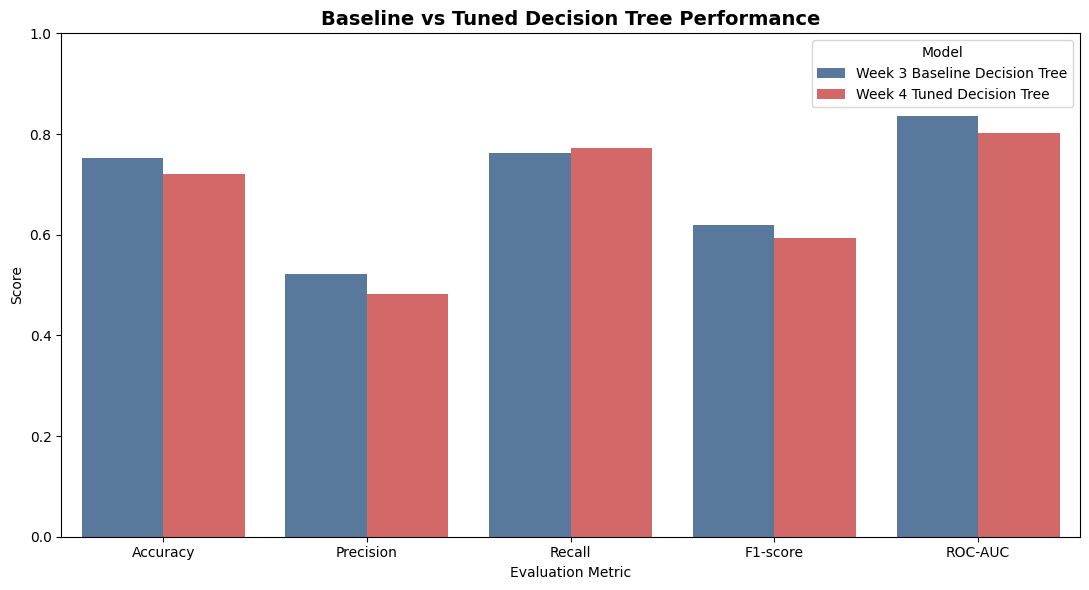

In [11]:
plot_data = comparison_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#4C78A8", "#E45756"]
)

plt.title(
    "Baseline vs Tuned Decision Tree Performance",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")

plt.tight_layout()
plt.savefig("week4_graphs/baseline_vs_tuned_metrics.png", dpi=300)
plt.show()

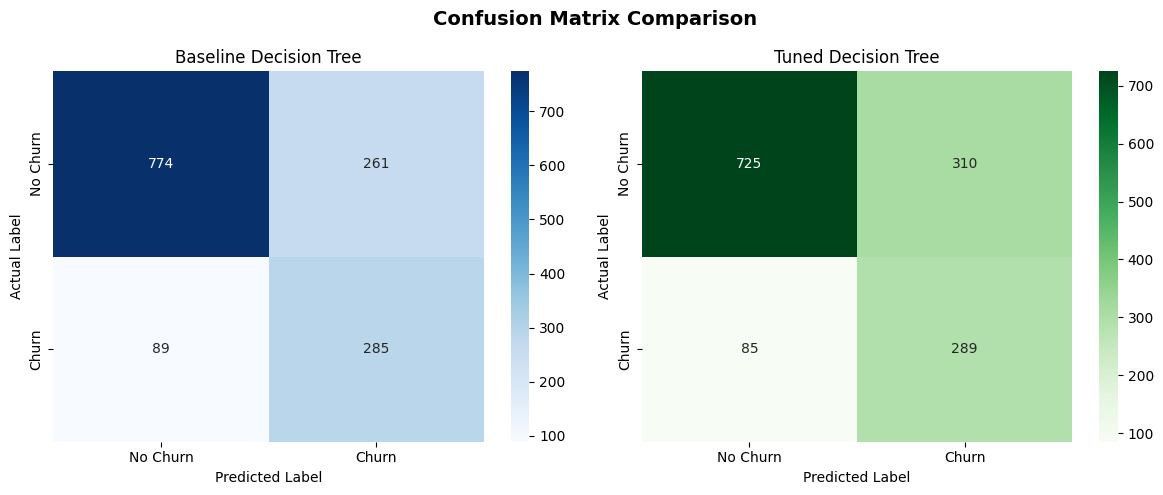

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

baseline_cm = confusion_matrix(y_test, baseline_predictions)
tuned_cm = confusion_matrix(y_test, tuned_predictions)

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    ax=axes[0]
)
axes[0].set_title("Baseline Decision Tree")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    ax=axes[1]
)
axes[1].set_title("Tuned Decision Tree")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("week4_graphs/confusion_matrix_comparison.png", dpi=300)
plt.show()

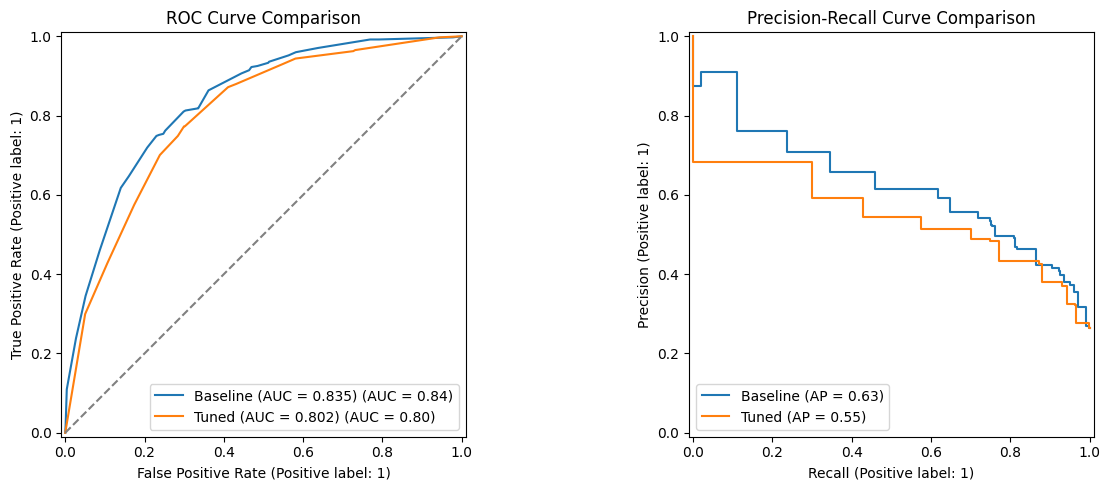

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    baseline_probabilities,
    name=f"Baseline (AUC = {baseline_metrics['ROC-AUC']:.3f})",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    tuned_probabilities,
    name=f"Tuned (AUC = {tuned_metrics['ROC-AUC']:.3f})",
    ax=axes[0]
)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve Comparison")

PrecisionRecallDisplay.from_predictions(
    y_test,
    baseline_probabilities,
    name="Baseline",
    ax=axes[1]
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    tuned_probabilities,
    name="Tuned",
    ax=axes[1]
)

axes[1].set_title("Precision-Recall Curve Comparison")

plt.tight_layout()
plt.savefig("week4_graphs/roc_pr_curve_comparison.png", dpi=300)
plt.show()

## Final Model Evaluation

After hyperparameter tuning, the baseline and tuned Decision Tree models are evaluated on the same held-out test set. The evaluation uses accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, ROC curves, and Precision-Recall curves.

Using the same test set for both models ensures that the comparison is fair and reproducible.

In [14]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (5634, 26)
Testing set shape: (1409, 26)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [16]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(random_search.best_score_)

Best Parameters:
{'model__min_samples_split': 40, 'model__min_samples_leaf': 15, 'model__max_features': 'log2', 'model__max_depth': 4, 'model__criterion': 'gini', 'model__class_weight': 'balanced'}

Best Cross-Validation F1-score:
0.6166430235981407


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Baseline predictions
y_pred_baseline = baseline_model.predict(X_test)

# Probability predictions for ROC-AUC
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1-score": f1_score(y_test, y_pred_baseline),
    "ROC-AUC": roc_auc_score(y_test, y_prob_baseline)
}

print("BASELINE DECISION TREE PERFORMANCE")
print("=" * 45)

for metric, score in baseline_results.items():
    print(f"{metric}: {score:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["No Churn", "Churn"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

BASELINE DECISION TREE PERFORMANCE
Accuracy: 0.7516
Precision: 0.5220
Recall: 0.7620
F1-score: 0.6196
ROC-AUC: 0.8353

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Confusion Matrix:
[[774 261]
 [ 89 285]]


In [20]:
comparison_results = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Tuned Decision Tree"
    ],
    "Accuracy": [
        baseline_results["Accuracy"],
        tuned_metrics["Accuracy"]
    ],
    "Precision": [
        baseline_results["Precision"],
        tuned_metrics["Precision"]
    ],
    "Recall": [
        baseline_results["Recall"],
        tuned_metrics["Recall"]
    ],
    "F1-score": [
        baseline_results["F1-score"],
        tuned_metrics["F1-score"]
    ],
    "ROC-AUC": [
        baseline_results["ROC-AUC"],
        tuned_metrics["ROC-AUC"]
    ]
})

comparison_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline Decision Tree,0.7516,0.5220,0.7620,0.6196,0.8353
1,Tuned Decision Tree,0.7197,0.4825,0.7727,0.5940,0.8016


In [22]:
metric_changes = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_results["Accuracy"],
        baseline_results["Precision"],
        baseline_results["Recall"],
        baseline_results["F1-score"],
        baseline_results["ROC-AUC"]
    ],
    "Tuned": [
        tuned_metrics["Accuracy"],
        tuned_metrics["Precision"],
        tuned_metrics["Recall"],
        tuned_metrics["F1-score"],
        tuned_metrics["ROC-AUC"]
    ]
})

metric_changes["Change"] = metric_changes["Tuned"] - metric_changes["Baseline"]

metric_changes.round(4)

,Metric,Baseline,Tuned,Change
0,Accuracy,0.7516,0.7197,-0.0319
1,Precision,0.5220,0.4825,-0.0395
2,Recall,0.7620,0.7727,0.0107
3,F1-score,0.6196,0.5940,-0.0255
4,ROC-AUC,0.8353,0.8016,-0.0338


In [24]:
# Final evaluation of the tuned Decision Tree

tuned_model = random_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("# TUNED DECISION TREE PERFORMANCE")
print()

print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["No Churn", "Churn"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

# TUNED DECISION TREE PERFORMANCE

Accuracy: 0.7197
Precision: 0.4825
Recall: 0.7727
F1-score: 0.5940
ROC-AUC: 0.8016

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1035
       Churn       0.48      0.77      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.73      1409

Confusion Matrix:
[[725 310]
 [ 85 289]]


## Cross-Validation Evaluation of the Tuned Model

After selecting the best hyperparameters using Grid Search, the tuned Decision Tree was further evaluated using 5-fold Stratified Cross-Validation. Multiple evaluation metrics were used to assess the model's performance and stability across different subsets of the training data.

The selected metrics were Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluation metrics
scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

# Cross-validation of the final tuned model
tuned_cv_results = cross_validate(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Calculate mean and standard deviation
tuned_cv_summary = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Mean": [
        tuned_cv_results["test_Accuracy"].mean(),
        tuned_cv_results["test_Precision"].mean(),
        tuned_cv_results["test_Recall"].mean(),
        tuned_cv_results["test_F1-score"].mean(),
        tuned_cv_results["test_ROC-AUC"].mean()
    ],
    "Std": [
        tuned_cv_results["test_Accuracy"].std(),
        tuned_cv_results["test_Precision"].std(),
        tuned_cv_results["test_Recall"].std(),
        tuned_cv_results["test_F1-score"].std(),
        tuned_cv_results["test_ROC-AUC"].std()
    ]
})

print("TUNED CROSS-VALIDATION MEAN SCORES")
print("=" * 45)

display(tuned_cv_summary.round(4))

TUNED CROSS-VALIDATION MEAN SCORES


,Metric,Mean,Std
0,Accuracy,0.7364,0.0133
1,Precision,0.5028,0.0172
2,Recall,0.7987,0.0298
3,F1-score,0.6166,0.0136
4,ROC-AUC,0.8134,0.0094


## Final Model Performance Visualizations

The final baseline and tuned Decision Tree models are compared using ROC curves, Precision-Recall curves, confusion matrices, and evaluation metrics. All visualizations are generated using the same final test set to ensure a fair and consistent comparison.

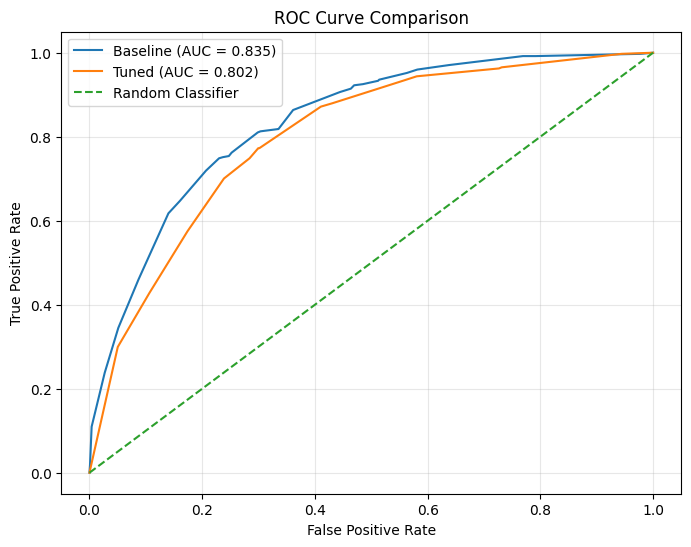

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curves
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_prob_baseline)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

auc_baseline = auc(fpr_baseline, tpr_baseline)
auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"Baseline (AUC = {auc_baseline:.3f})"
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Tuned (AUC = {auc_tuned:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()



### Precision-Recall Curve Comparison

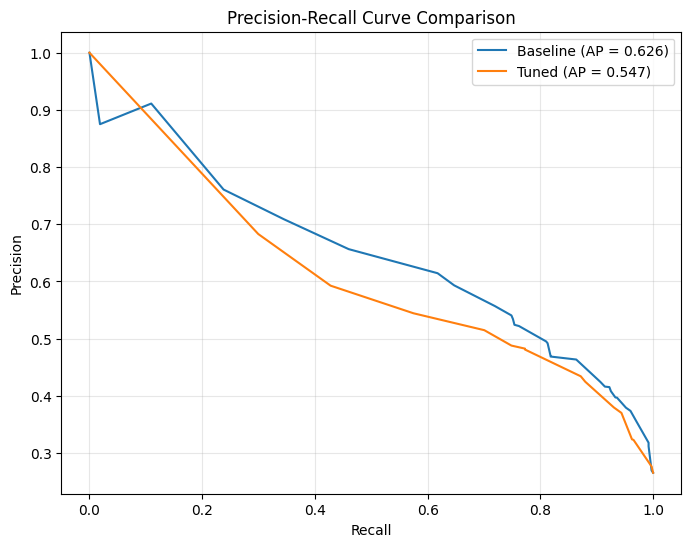

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curves
precision_baseline, recall_baseline, _ = precision_recall_curve(
    y_test,
    y_prob_baseline
)

precision_tuned, recall_tuned, _ = precision_recall_curve(
    y_test,
    y_prob_tuned
)

ap_baseline = average_precision_score(y_test, y_prob_baseline)
ap_tuned = average_precision_score(y_test, y_prob_tuned)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_baseline,
    precision_baseline,
    label=f"Baseline (AP = {ap_baseline:.3f})"
)

plt.plot(
    recall_tuned,
    precision_tuned,
    label=f"Tuned (AP = {ap_tuned:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

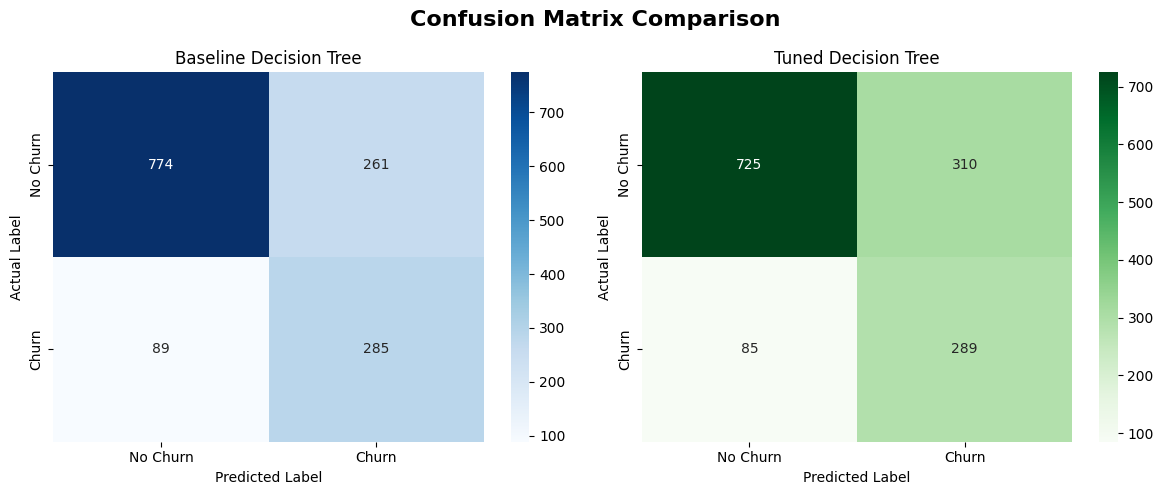

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

axes[0].set_title("Baseline Decision Tree")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

axes[1].set_title("Tuned Decision Tree")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

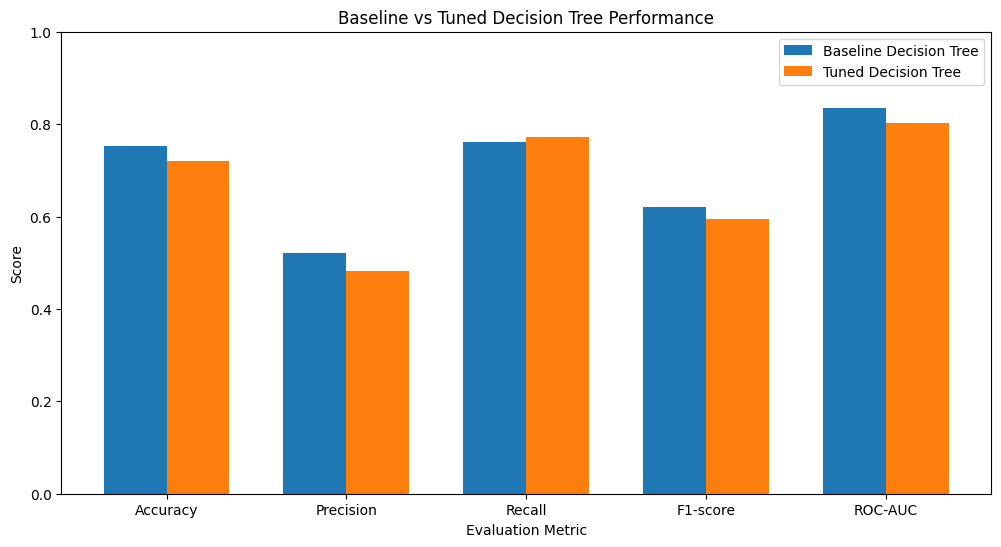

In [30]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

baseline_scores = [
    baseline_results["Accuracy"],
    baseline_results["Precision"],
    baseline_results["Recall"],
    baseline_results["F1-score"],
    baseline_results["ROC-AUC"]
]

tuned_scores = [
    tuned_metrics["Accuracy"],
    tuned_metrics["Precision"],
    tuned_metrics["Recall"],
    tuned_metrics["F1-score"],
    tuned_metrics["ROC-AUC"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    baseline_scores,
    width,
    label="Baseline Decision Tree"
)

plt.bar(
    x + width/2,
    tuned_scores,
    width,
    label="Tuned Decision Tree"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Baseline vs Tuned Decision Tree Performance")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

plt.show()

# Final Findings and Interpretation

## Model Comparison

The baseline and tuned Decision Tree models were evaluated using the same held-out test set of 1,409 customers. Multiple evaluation metrics were considered to provide a comprehensive assessment of model performance.

The baseline Decision Tree achieved an accuracy of 0.7516, precision of 0.5220, recall of 0.7620, F1-score of 0.6196, and ROC-AUC of 0.8353.

The tuned Decision Tree achieved an accuracy of 0.7197, precision of 0.4825, recall of 0.7727, F1-score of 0.5940, and ROC-AUC of 0.8016.

The results indicate that hyperparameter tuning did not improve the overall performance of the Decision Tree. However, the tuned model achieved a slightly higher recall, increasing from 0.7620 to 0.7727. This means that the tuned model was able to identify a slightly larger proportion of customers who actually churned.

This improvement in recall came at the cost of lower precision, accuracy, F1-score, and ROC-AUC. Therefore, the tuned model generated more false-positive churn predictions while detecting slightly more actual churners.

## Cross-Validation Findings

Five-fold Stratified Cross-Validation was used to evaluate the stability of the models across different training and validation subsets.

The tuned model achieved the following mean cross-validation results:

- Accuracy: 0.7364 ± 0.0133
- Precision: 0.5028 ± 0.0172
- Recall: 0.7987 ± 0.0298
- F1-score: 0.6166 ± 0.0136
- ROC-AUC: 0.8134 ± 0.0094

The relatively small standard deviations indicate that the model's performance was reasonably stable across the five folds.

## Hyperparameter Tuning Findings

Grid Search was used to identify a suitable combination of Decision Tree hyperparameters. A total of 50 parameter combinations were evaluated using 5-fold cross-validation, resulting in 250 model fits.

The best configuration used:

- Criterion: Gini
- Maximum depth: 4
- Maximum features: log2
- Minimum samples split: 40
- Minimum samples leaf: 15
- Class weight: balanced

The best cross-validation F1-score was 0.6166.

The selected configuration produces a relatively constrained tree by limiting its depth and requiring a larger number of observations for node splitting and leaf creation. The balanced class-weight setting gives greater importance to the minority churn class.

## Business Interpretation

From a business perspective, recall is particularly important when the cost of missing a potential churn customer is high. The tuned model achieved a recall of 0.7727 compared with 0.7620 for the baseline model.

However, the tuned model also produced more false-positive predictions. The confusion matrix shows that false positives increased from 261 in the baseline model to 310 in the tuned model.

Therefore, the choice between the two models depends on the business objective. If the organization prioritizes identifying as many potential churners as possible, the tuned model may be useful. If the organization wants stronger overall predictive performance and fewer unnecessary retention interventions, the baseline model is preferable.

## Overall Conclusion

Hyperparameter tuning successfully demonstrated how model parameters and class weighting can change the balance between precision and recall. Although the tuned model slightly improved recall, it did not outperform the baseline Decision Tree on overall accuracy, precision, F1-score, ROC-AUC, or Precision-Recall performance.

Based on the final test-set results, the baseline Decision Tree is the preferred model for overall predictive performance. Nevertheless, the tuned model provides a useful alternative when the primary business objective is to minimize missed churn customers.

The experiment demonstrates that hyperparameter tuning does not always increase every performance metric. Instead, model selection should consider the business objective, class imbalance, evaluation metrics, and the cost associated with different types of prediction errors.

## Limitations

1. **Dataset-specific nature:** The model was developed using a single Telco Customer Churn dataset, so its performance may not generalize to other telecom companies or customer populations.

2. **Class imbalance:** Churn represents a minority class in the dataset. Although class weighting was considered during tuning, class imbalance can still influence model performance.

3. **Model limitations:** Decision Trees can have limitations when dealing with complex relationships between customer characteristics. More advanced ensemble models may provide better predictive performance.

4. **Limited hyperparameter search:** The Grid Search explored a predefined set of hyperparameters. Other combinations or optimization approaches may produce different results.

5. **Static customer information:** The dataset represents customer information at a particular point in time. Customer behavior can change over time, which may affect prediction performance in real-world applications.

6. **No external validation:** The final model was evaluated using a held-out test set from the same dataset. Testing the model on an independent external dataset would provide stronger evidence of generalization.

## Recommendations for Future Work

Future improvements could include:

1. **Evaluate ensemble models:** Random Forest, Gradient Boosting, XGBoost, or other ensemble methods could be compared with the Decision Tree.

2. **Optimize the classification threshold:** Instead of relying only on the default 0.5 probability threshold, the threshold could be adjusted according to the business cost of false positives and false negatives.

3. **Use model explainability:** SHAP or feature importance analysis could be used to identify the factors that contribute most strongly to customer churn.

4. **Cost-sensitive modeling:** Different costs can be assigned to false negatives and false positives to align model predictions with business priorities.

5. **External validation:** The final model should be tested on new customer data to determine whether it generalizes beyond the current dataset.

6. **Model monitoring:** In a real-world deployment, model performance should be monitored regularly because customer behavior and business conditions can change over time.

# Week 4 Task Summary

### Completed Components

- Advanced model evaluation
- 5-fold Stratified Cross-Validation
- Accuracy, Precision, Recall, F1-score and ROC-AUC analysis
- Hyperparameter tuning using Grid Search
- Evaluation of 50 hyperparameter combinations
- 250 total cross-validation fits
- Selection of the best Decision Tree configuration
- Final tuned model evaluation
- Confusion Matrix comparison
- ROC Curve comparison
- Precision-Recall Curve comparison
- Baseline vs Tuned performance comparison
- Analysis of model trade-offs
- Business interpretation
- Limitations
- Future recommendations

### Final Model Decision

Based on the final test-set evaluation, the **Baseline Decision Tree** is selected as the preferred model for overall predictive performance because it achieved higher Accuracy, Precision, F1-score and ROC-AUC.

The **Tuned Decision Tree** achieved slightly higher Recall and may be preferred when the business objective is to identify as many potential churn customers as possible.